In [31]:
import pandas as pd
import numpy as np
import joblib
from collections import defaultdict, deque
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import mlflow
pd.set_option('display.max_columns', None)


pokemon = pd.read_csv("data/final_pokemon.csv")
combat = pd.read_csv("data/final_combats.csv")

## Pre-processing

In [32]:
pokemon.isnull().values.any(), combat.isnull().values.any()

(np.False_, np.False_)

In [33]:
pokemon.head(3) # contains glossary of pokemon and their information

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,height,weight,base_experience,sprites
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,7,69,64,{'normal': 'http://img.pokemondb.net/sprites/b...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,10,130,142,{'normal': 'http://img.pokemondb.net/sprites/b...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,20,1000,236,{'normal': 'http://img.pokemondb.net/sprites/b...


In [34]:
combat.head(3) # contains results from simulated battles using the pokemon IDs (#)

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668


In [35]:
merged = combat.merge(pokemon, how="left", left_on="First_pokemon", right_on="#")
merged = merged.merge(pokemon, how="left", left_on="Second_pokemon", right_on="#", suffixes=("_first", "_second"))
merged = merged.merge(pokemon[['Name',"#"]], how="left", left_on="Winner",right_on="#")

merged = merged.drop(columns=['#', 'Winner','First_pokemon', 'Second_pokemon', '#_first', '#_second','sprites_first','sprites_second'])
merged = merged.rename(columns = {'Name':'Winner_name'})

merged["Winner_label"] = merged.apply( # assign Winner label based on which of the two pokemon in a battle won
    lambda row: "first" if row["Name_first"] == row["Winner_name"] else "second",
    axis=1
)
merged.head(5)

,Name_first,Type 1_first,Type 2_first,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first,Generation_first,Legendary_first,height_first,weight_first,base_experience_first,Name_second,Type 1_second,Type 2_second,HP_second,Attack_second,Defense_second,Sp. Atk_second,Sp. Def_second,Speed_second,Generation_second,Legendary_second,height_second,weight_second,base_experience_second,Winner_name,Winner_label
0,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,6,720,60,Nuzleaf,Grass,Dark,70,70,40,60,40,60,3,False,10,280,119,Nuzleaf,second
1,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True,20,2000,261,Terrakion,Rock,Fighting,91,129,90,72,90,108,5,True,19,2600,261,Terrakion,second
2,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False,6,32,142,Beheeyem,Psychic,Normal,75,75,75,125,95,40,5,False,10,345,170,Beheeyem,second
3,Slugma,Fire,Normal,40,40,40,70,40,20,2,False,7,350,50,Druddigon,Dragon,Normal,77,120,90,60,90,48,5,False,16,1390,170,Druddigon,second
4,Omastar,Rock,Water,70,60,125,115,70,55,1,False,10,350,173,Shuckle,Bug,Rock,20,10,230,10,230,5,2,False,6,205,177,Omastar,first


In [36]:
merged[['Name_first','Name_second','Winner_name', 'Winner_label']].head() # check if Winner_label correctly assigned

,Name_first,Name_second,Winner_name,Winner_label
0,Larvitar,Nuzleaf,Nuzleaf,second
1,Virizion,Terrakion,Terrakion,second
2,Togetic,Beheeyem,Beheeyem,second
3,Slugma,Druddigon,Druddigon,second
4,Omastar,Shuckle,Omastar,first


In [37]:
merged.columns # check

Index(['Name_first', 'Type 1_first', 'Type 2_first', 'HP_first',
       'Attack_first', 'Defense_first', 'Sp. Atk_first', 'Sp. Def_first',
       'Speed_first', 'Generation_first', 'Legendary_first', 'height_first',
       'weight_first', 'base_experience_first', 'Name_second', 'Type 1_second',
       'Type 2_second', 'HP_second', 'Attack_second', 'Defense_second',
       'Sp. Atk_second', 'Sp. Def_second', 'Speed_second', 'Generation_second',
       'Legendary_second', 'height_second', 'weight_second',
       'base_experience_second', 'Winner_name', 'Winner_label'],
      dtype='object')

In [38]:
# Build graph

graph = defaultdict(list)

for _, row in merged.iterrows():

    winner = row['Winner_name']
    loser = row['Name_second'] if winner == row['Name_first'] else row['Name_first']

    graph[winner].append(loser)

In [39]:
def dfs(pokemon, graph, visited):

    if pokemon in visited:
        return 
    visited.add(pokemon)
    
    for opponent in graph[pokemon]:
        dfs(opponent, graph, visited)


visited = set()
dfs("Tepig", graph, visited)
visited


{'Abomasnow',
 'Abra',
 'Absol',
 'Accelgor',
 'Aerodactyl',
 'Aggron',
 'Aipom',
 'Alakazam',
 'Alomomola',
 'Altaria',
 'Amaura',
 'Ambipom',
 'Amoonguss',
 'Ampharos',
 'Anorith',
 'Arbok',
 'Arcanine',
 'Arceus',
 'Archen',
 'Archeops',
 'Armaldo',
 'Aromatisse',
 'Aron',
 'Articuno',
 'Audino',
 'Aurorus',
 'Avalugg',
 'Axew',
 'Azelf',
 'Azumarill',
 'Azurill',
 'Bagon',
 'Baltoy',
 'Banette',
 'Barbaracle',
 'Barboach',
 'Bastiodon',
 'Bayleef',
 'Beartic',
 'Beautifly',
 'Beedrill',
 'Beheeyem',
 'Beldum',
 'Bellossom',
 'Bellsprout',
 'Bergmite',
 'Bibarel',
 'Bidoof',
 'Binacle',
 'Bisharp',
 'Blaziken',
 'Blissey',
 'Blitzle',
 'Boldore',
 'Bonsly',
 'Bouffalant',
 'Braixen',
 'Braviary',
 'Breloom',
 'Bronzong',
 'Bronzor',
 'Budew',
 'Buizel',
 'Bulbasaur',
 'Buneary',
 'Bunnelby',
 'Burmy',
 'Butterfree',
 'Cacnea',
 'Cacturne',
 'Camerupt',
 'Carbink',
 'Carnivine',
 'Carracosta',
 'Carvanha',
 'Cascoon',
 'Castform',
 'Caterpie',
 'Celebi',
 'Chandelure',
 'Chansey',
 '

In [40]:
model_df = merged.drop(columns=['Name_first','Name_second','Winner_name']) # will label-encode the winner later

categorical_features = ['Type 1_first','Type 2_first','Type 1_second','Type 2_second',
                        'Legendary_first', 'Legendary_second', 
                        'Generation_first','Generation_second']


encoder = OneHotEncoder() # instantiate OHE
encoder.fit(model_df[categorical_features]) # fit encoder
joblib.dump(encoder, "models/poke_encoder.pkl")    # save fitted encoder

encoded_data = encoder.transform(model_df[categorical_features])

encoded_df = pd.DataFrame(encoded_data.toarray(), 
                          columns=encoder.get_feature_names_out(categorical_features),
                          index=model_df.index)

model_df_encoded = pd.concat([model_df, encoded_df], axis=1)
model_df_encoded.drop(columns=categorical_features,axis=1,inplace=True)

model_df_encoded.head()

,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first,height_first,weight_first,base_experience_first,HP_second,Attack_second,Defense_second,Sp. Atk_second,Sp. Def_second,Speed_second,height_second,weight_second,base_experience_second,Winner_label,Type 1_first_Bug,Type 1_first_Dark,Type 1_first_Dragon,Type 1_first_Electric,Type 1_first_Fairy,Type 1_first_Fighting,Type 1_first_Fire,Type 1_first_Flying,Type 1_first_Ghost,Type 1_first_Grass,Type 1_first_Ground,Type 1_first_Ice,Type 1_first_Normal,Type 1_first_Poison,Type 1_first_Psychic,Type 1_first_Rock,Type 1_first_Steel,Type 1_first_Water,Type 2_first_Bug,Type 2_first_Dark,Type 2_first_Dragon,Type 2_first_Electric,Type 2_first_Fairy,Type 2_first_Fighting,Type 2_first_Fire,Type 2_first_Flying,Type 2_first_Ghost,Type 2_first_Grass,Type 2_first_Ground,Type 2_first_Ice,Type 2_first_Normal,Type 2_first_Poison,Type 2_first_Psychic,Type 2_first_Rock,Type 2_first_Steel,Type 2_first_Water,Type 1_second_Bug,Type 1_second_Dark,Type 1_second_Dragon,Type 1_second_Electric,Type 1_second_Fairy,Type 1_second_Fighting,Type 1_second_Fire,Type 1_second_Flying,Type 1_second_Ghost,Type 1_second_Grass,Type 1_second_Ground,Type 1_second_Ice,Type 1_second_Normal,Type 1_second_Poison,Type 1_second_Psychic,Type 1_second_Rock,Type 1_second_Steel,Type 1_second_Water,Type 2_second_Bug,Type 2_second_Dark,Type 2_second_Dragon,Type 2_second_Electric,Type 2_second_Fairy,Type 2_second_Fighting,Type 2_second_Fire,Type 2_second_Flying,Type 2_second_Ghost,Type 2_second_Grass,Type 2_second_Ground,Type 2_second_Ice,Type 2_second_Normal,Type 2_second_Poison,Type 2_second_Psychic,Type 2_second_Rock,Type 2_second_Steel,Type 2_second_Water,Legendary_first_False,Legendary_first_True,Legendary_second_False,Legendary_second_True,Generation_first_1,Generation_first_2,Generation_first_3,Generation_first_4,Generation_first_5,Generation_first_6,Generation_second_1,Generation_second_2,Generation_second_3,Generation_second_4,Generation_second_5,Generation_second_6
0,50,64,50,45,50,41,6,720,60,70,70,40,60,40,60,10,280,119,second,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,91,90,72,90,129,108,20,2000,261,91,129,90,72,90,108,19,2600,261,second,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,55,40,85,80,105,40,6,32,142,75,75,75,125,95,40,10,345,170,second,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40,40,40,70,40,20,7,350,50,77,120,90,60,90,48,16,1390,170,second,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,70,60,125,115,70,55,10,350,173,20,10,230,10,230,5,6,205,177,first,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

## Model Training

In [41]:
X = model_df_encoded.drop(columns=["Winner_label"]) # features
y = model_df_encoded['Winner_label'].map({'first':0, 'second':1})    # labels

X_train, X_test, y_train, y_test = train_test_split(X, y)

#### Logistic Regression

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)                    # train model
joblib.dump(lr, "models/poke_lr.pkl")              # save trained model

y_pred_test = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

test_accuracy = accuracy_score(y_pred_test, y_test)
train_accuracy = accuracy_score(y_pred_train, y_train)

test_recall = recall_score(y_pred_test, y_test)
train_recall = recall_score(y_pred_train, y_train)

test_precision = precision_score(y_pred_test, y_test)
train_precision = precision_score(y_pred_train, y_train)


eval_df = pd.DataFrame({'Metric' : ['Accuracy', 'Recall', 'Precision'],
                        'Test' : [test_accuracy, test_recall, test_precision],
                        'Train' : [train_accuracy, train_recall, train_precision]
                        })
eval_df

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Metric,Test,Train
0,Accuracy,0.886693,0.887561
1,Recall,0.892039,0.890888
2,Precision,0.891322,0.898351


#### Random Forest

In [ ]:
rfc = RandomForestClassifier(n_estimators=100,
                             max_depth= 10,
                             criterion= 'log_loss'
                             )

rfc.fit(X_train, y_train)                    # train model
joblib.dump(rfc, "models/poke_rfc.pkl")             # save trained model

y_pred_test = rfc.predict(X_test)
y_pred_train = rfc.predict(X_train)

test_accuracy = accuracy_score(y_pred_test, y_test)
train_accuracy = accuracy_score(y_pred_train, y_train)

test_recall = recall_score(y_pred_test, y_test)
train_recall = recall_score(y_pred_train, y_train)

test_precision = precision_score(y_pred_test, y_test)
train_precision = precision_score(y_pred_train, y_train)


eval_df = pd.DataFrame({'Metric' : ['Accuracy', 'Recall', 'Precision'],
                        'Test' : [test_accuracy, test_recall, test_precision],
                        'Train' : [train_accuracy, train_recall, train_precision]
                        })
eval_df

,Metric,Test,Train
0,Accuracy,0.897204,0.923090
1,Recall,0.902253,0.925110
2,Precision,0.901165,0.930541


#### Gradient Boosting

In [ ]:
gbc = GradientBoostingClassifier(n_estimators=500, max_depth=4, learning_rate=0.1, random_state=23)

gbc.fit(X_train, y_train)                    # train model
joblib.dump(gbc, "models/poke_gbc.pkl")      # save trained model

y_pred_test = gbc.predict(X_test)
y_pred_train = gbc.predict(X_train)

test_accuracy = accuracy_score(y_pred_test, y_test)
train_accuracy = accuracy_score(y_pred_train, y_train)

test_recall = recall_score(y_pred_test, y_test)
train_recall = recall_score(y_pred_train, y_train)

test_precision = precision_score(y_pred_test, y_test)
train_precision = precision_score(y_pred_train, y_train)


eval_df = pd.DataFrame({'Metric' : ['Accuracy', 'Recall', 'Precision'],
                        'Test' : [test_accuracy, test_recall, test_precision],
                        'Train' : [train_accuracy, train_recall, train_precision]
                        })
eval_df

,Metric,Test,Train
0,Accuracy,0.963633,0.981605
1,Recall,0.966693,0.982501
2,Precision,0.964780,0.982697


#### Neural Network

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

input_size = X_train.shape[1]

In [66]:
# Design model

class nn_model(nn.Module):
    def __init__(self, input_size):
        super(nn_model,self).__init__()

        self.linear1 = nn.Linear(input_size, 512)
        self.linear1_2 = nn.Linear(512, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, 32)
        self.linear4 = nn.Linear(32, 16)
        self.linear5 = nn.Linear(16, 1) # only 1 output since binary

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.30)


    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.dropout(x)
        x = self.relu(self.linear1_2(x))
        x = self.dropout(x)
        x = self.relu(self.linear2(x))
        x = self.dropout(x)             # apply after each dense layer
        x = self.relu(self.linear3(x))
        x = self.relu(self.linear4(x))
        x = self.linear5(x)

        return x


Epoch [200/1600], Train Loss: 0.2112
Epoch [400/1600], Train Loss: 0.1493
Epoch [600/1600], Train Loss: 0.1111
Epoch [800/1600], Train Loss: 0.0844
Epoch [1000/1600], Train Loss: 0.0673
Epoch [1200/1600], Train Loss: 0.0578
Epoch [1400/1600], Train Loss: 0.0440
Epoch [1600/1600], Train Loss: 0.0397


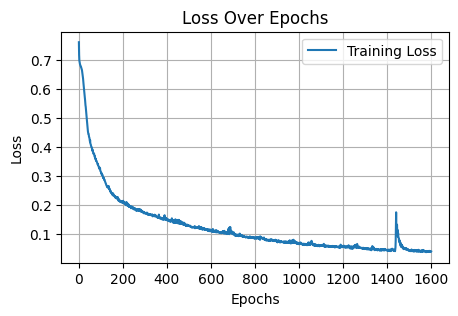

In [67]:
# Initialize
model = nn_model(input_size)
criterion = nn.BCEWithLogitsLoss()                        
optimizer = optim.Adam(model.parameters(), lr=0.001)     


# Training loop
num_epochs = 1_600
losses = []

for epoch in range(num_epochs): 
    model.train()                                 # set model to training mode
    outputs = model(X_train_tensor)               # feeds training data into model, gets predicted outputs (logits)
    loss = criterion(outputs, y_train_tensor)     # uses loss function to compare

    optimizer.zero_grad()                         # reset the gradients
    loss.backward()                               # compute gradients
    optimizer.step()                              # update model weights to reduce loss

    losses.append(loss.item())                    # collect losses for plotting


    if (epoch + 1) % 200 == 0:  # print losses
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# Plot loss curve
plt.figure(figsize=(5,3))
plt.plot(range(1, num_epochs + 1), losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

In [68]:
model.eval()

with torch.no_grad():
    y_test_logits = model(X_test_tensor)               # shape: (N, 1)
    y_test_probs = torch.sigmoid(y_test_logits)             # convert logits to probabilities
    y_pred_test_np = (y_test_probs >= 0.5).int().squeeze().numpy()  # binary predictions (0 or 1)
    y_test_np = y_test_tensor.squeeze().numpy()

    y_train_logits = model(X_train_tensor)               # shape: (N, 1)
    y_train_probs = torch.sigmoid(y_train_logits)             # convert logits to probabilities
    y_pred_train_np = (y_train_probs >= 0.5).int().squeeze().numpy()  # binary predictions (0 or 1)
    y_test_np = y_test_tensor.squeeze().numpy()



test_accuracy = accuracy_score(y_test_np, y_pred_test_np)
train_accuracy = accuracy_score(y_train_np, y_pred_train_np)
test_recall = recall_score(y_test_np, y_pred_test_np)
train_recall = recall_score(y_train_np, y_pred_train_np)
test_precision = precision_score(y_test_np, y_pred_test_np)
train_precision = precision_score(y_train_np, y_pred_train_np)

eval_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision'],
    'Test': [test_accuracy, test_recall, test_precision],
    'Train': [train_accuracy, train_recall, train_precision]
})
eval_df

,Metric,Test,Train
0,Accuracy,0.953122,0.995760
1,Recall,0.951919,0.995028
2,Precision,0.959513,0.996945


In [69]:
torch.save(model.state_dict(), "models/poke_nn.pt")   # save trained neural network classifier

The neural network doesn't outperform the Gradient Boosting Classifier and is much more complex, so we won't use it for the main app.

## Real-world Functionality

In [71]:
merged.head(3) # column check

,Name_first,Type 1_first,Type 2_first,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first,Generation_first,Legendary_first,height_first,weight_first,base_experience_first,Name_second,Type 1_second,Type 2_second,HP_second,Attack_second,Defense_second,Sp. Atk_second,Sp. Def_second,Speed_second,Generation_second,Legendary_second,height_second,weight_second,base_experience_second,Winner_name,Winner_label
0,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,6,720,60,Nuzleaf,Grass,Dark,70,70,40,60,40,60,3,False,10,280,119,Nuzleaf,second
1,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True,20,2000,261,Terrakion,Rock,Fighting,91,129,90,72,90,108,5,True,19,2600,261,Terrakion,second
2,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False,6,32,142,Beheeyem,Psychic,Normal,75,75,75,125,95,40,5,False,10,345,170,Beheeyem,second


In [ ]:
def create_matchup_df(name1, name2):
    
    # Look up names
    name1 = name1.strip().title()
    name2 = name2.strip().title()
    
    p1_row = pokemon[pokemon['Name'] == name1]
    p2_row = pokemon[pokemon['Name'] == name2]

    if p1_row.empty or p2_row.empty:
        raise ValueError("One or both Pokémon names not found.")

    p1_id = p1_row.iloc[0]["#"]
    p2_id = p2_row.iloc[0]["#"]


    # Create row for the matchup
    matchup = pd.DataFrame({
        "First_pokemon": [p1_id],
        "Second_pokemon": [p2_id],
        "Winner": [None]
    })


    merged = matchup.merge(pokemon, how="left", left_on="First_pokemon", right_on="#")
    merged = merged.merge(pokemon, how="left", left_on="Second_pokemon", right_on="#", suffixes=("_first", "_second"))
    merged = merged.drop(columns=['#_first', '#_second', 'sprites_first', 'sprites_second', 'Winner', 'First_pokemon', 'Second_pokemon'])

    return merged

In [73]:
def pipeline(data, model_path, encoder_path, first_pokemon, second_pokemon): # should just take in the pokemon names and model to use
    
    model_df = data.drop(columns=['Name_first','Name_second'])

    categorical_features = ['Type 1_first','Type 2_first','Type 1_second','Type 2_second',
                            'Legendary_first', 'Legendary_second', 
                            'Generation_first','Generation_second']


    encoder = joblib.load(encoder_path)
    encoded_data = encoder.transform(model_df[categorical_features]) # fit and transform the data
    encoded_df = pd.DataFrame(encoded_data.toarray(), 
                            columns=encoder.get_feature_names_out(categorical_features),
                            index=model_df.index)

    model_df_encoded = pd.concat([model_df, encoded_df], axis=1)
    model_df_encoded.drop(columns=categorical_features,axis=1,inplace=True)
    

    model = joblib.load(model_path)
    required_columns = list(model.feature_names_in_)
    
    for col in required_columns:
        if col not in model_df_encoded.columns:
            model_df_encoded[col] = 0.0

    model_df_encoded = model_df_encoded[required_columns]

    y_pred_prob = model.predict_proba(model_df_encoded)
    y_pred = model.predict(model_df_encoded)

    y_pred_label = [first_pokemon if pred == 0 else second_pokemon for pred in y_pred]

    print(f"Predicted Winner: %s" % (y_pred_label[0]))
    print(f"Chance of Winning: {100*np.max(y_pred_prob):.2f}%")

**Execution:**

In [75]:
first_pokemon = "Arceus"
second_pokemon = "Gyarados"

model_path = "models/poke_gbc.pkl"
encoder_path = "models/poke_encoder.pkl"

matchup_df = create_matchup_df(first_pokemon, second_pokemon)
pipeline(matchup_df, model_path, encoder_path, first_pokemon, second_pokemon)

Predicted Winner: Arceus
Chance of Winning: 99.70%


In [76]:
# Pokemon Name Lookup
search = "Gyarados"
pokemon[pokemon['Name']==search]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,height,weight,base_experience,sprites
124,141,Gyarados,Water,Flying,95,125,79,60,100,81,1,False,65,2350,189,{'normal': 'http://img.pokemondb.net/sprites/b...
